# Example Notebook For `jact`

This notebook walks through the main `jact` workflow end to end on a small illness-death model. The example stays CPU-friendly and focuses on the pieces a first-time user usually needs:

1. define a `StateSpace`
2. attach JAX-native transition intensities with `build(...)`
3. solve transition probabilities for a batch of individuals
4. inspect `result.states` and `result.probability`
5. finish with one advanced `InitialDistribution` example


## What `jact` does

`jact` separates the **state topology** from the **intensity models** that live on that topology. You can reuse the same `StateSpace` with different hazard specifications, then ask the solver for transition probabilities for one person or a large batch.

In this notebook we use three states:

- `healthy`
- `disabled`
- `dead`

with transitions `healthy -> disabled`, `healthy -> dead`, and `disabled -> dead`.


In [1]:
import jact
import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt


In [2]:
state_space = jact.StateSpace(
    states=["healthy", "disabled", "dead"],
    transitions=[
        ("healthy", "disabled"),
        ("healthy", "dead"),
        ("disabled", "dead"),
    ],
)

print(state_space)
print("absorbing =", state_space.absorbing)
print("exits from healthy =", state_space.exits("healthy"))


StateSpace(states=['healthy', 'disabled', 'dead'], transitions=[disabled->dead, healthy->dead, healthy->disabled])
absorbing = ('dead',)
exits from healthy = (('healthy', 'disabled'), ('healthy', 'dead'))


## Define intensity functions

Each intensity callable receives clock time `t`, a duration grid `d`, and any batch covariates passed to `solve(...)`. Here we use a single covariate, `age`, and let the intensities depend on **attained age** (`age + t`) and, where useful, current-state duration `d`.

The solver expects each callable to return an array with shape `(batch, duration_grid)`.


In [3]:
def disability_onset(t, d, *, age):
    attained_age = age[:, None] + t
    return 0.02 + 0.0015 * (attained_age - 50.0) + 0.015 * jnp.exp(-d / 4.0)


def mortality_healthy(t, d, *, age):
    attained_age = age[:, None] + t
    return 0.005 + 0.0008 * (attained_age - 50.0) + jnp.zeros_like(d)


def mortality_disabled(t, d, *, age):
    attained_age = age[:, None] + t
    return 0.015 + 0.0012 * (attained_age - 50.0) + 0.01 * (1.0 - jnp.exp(-d / 3.0))


sample_age = jnp.array([45.0, 60.0])
duration_grid = jnp.linspace(0.0, 2.0, 5)[None, :]

print("healthy -> disabled sample")
print(jnp.round(disability_onset(0.0, duration_grid, age=sample_age), 4))


healthy -> disabled sample
[[0.0275 0.0257 0.0242 0.0228 0.0216]
 [0.05   0.0482 0.0467 0.0453 0.0441]]


In [4]:
model = state_space.build(
    transitions={
        ("healthy", "disabled"): disability_onset,
        ("healthy", "dead"): mortality_healthy,
        ("disabled", "dead"): mortality_disabled,
    }
)

ages = jnp.array([45.0, 60.0, 75.0])

result = model.solve(
    initial="healthy",
    horizon=15,
    steps_per_unit=12,
    record_every=12,
    probability=jact.probability.StateProbability(),
    age=ages,
)

print("states =", result.states)
print("probability shape =", result.probability.shape)
print("t = 0 probabilities")
print(jnp.round(result.probability[0], 4))
print(
    "maximum row-sum error =",
    float(jnp.max(jnp.abs(jnp.sum(result.probability, axis=-1) - 1.0))),
)


states = ('healthy', 'disabled', 'dead')
probability shape = (16, 3, 3)
t = 0 probabilities
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
maximum row-sum error = 1.1920928955078125e-07


## Read the solver output

- `result.states` tells you which state ordering was used in the solve result.
- `result.probability` is the actual probability array for the probability reducer you chose.
- With `probability=jact.probability.StateProbability()`, the shape is `(time, batch, states)` because duration has already been marginalised out.

In this run we recorded one point per year, so the leading dimension has length `16`: time `0` through time `15`.


<ipython-input-1-3d9a0f41f378>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


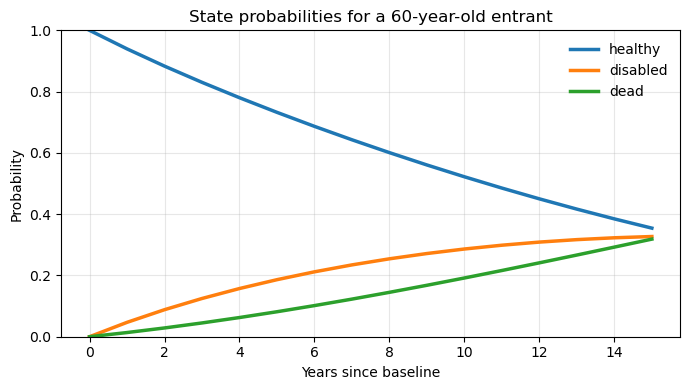

In [5]:
time_years = jnp.arange(result.probability.shape[0])
representative = result.probability[:, 1, :]

fig, ax = plt.subplots(figsize=(7, 4))
for idx, state in enumerate(result.states):
    ax.plot(time_years, representative[:, idx], linewidth=2.5, label=state)

ax.set_title("State probabilities for a 60-year-old entrant")
ax.set_xlabel("Years since baseline")
ax.set_ylabel("Probability")
ax.set_ylim(0.0, 1.0)
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Add cashflows

Cashflows are declared from the same `StateSpace` and then selected at solve time with `cashflow_views`. Streamed cashflows use interval semantics: with `horizon=15`, `steps_per_unit=12`, and `record_every=12`, each streamed leaf has 15 annual intervals, not the 16 probability snapshots that include time zero.


In [6]:
def annual_premium(t, d, *, age):
    return jnp.full((age.shape[0], d.shape[-1]), -1_200.0)


def death_benefit(t, d, *, age):
    return jnp.full((age.shape[0], d.shape[-1]), 100_000.0)


def bonus_time(*, age):
    return jnp.maximum(65.0 - age, 0.0)


def retirement_bonus(t, d, *, age):
    return jnp.full((age.shape[0], d.shape[-1]), 5_000.0)


cashflows = state_space.cashflows(
    {
        "premium": jact.cashflows.StateRate({"healthy": annual_premium}),
        "death_benefit": jact.cashflows.TransitionLump(
            {
                ("healthy", "dead"): death_benefit,
                ("disabled", "dead"): death_benefit,
            }
        ),
        "retirement_bonus": jact.cashflows.ScheduledEvent(
            when=bonus_time,
            payments={"healthy": retirement_bonus},
        ),
    }
)

cashflow_result = model.solve(
    initial="healthy",
    horizon=15,
    steps_per_unit=12,
    record_every=12,
    probability=None,
    cashflows=cashflows,
    cashflow_views={
        "raw": jact.cashflows.Raw(),
        "total_benefits": jact.cashflows.Group(["death_benefit", "retirement_bonus"]),
        "by_kind": jact.cashflows.ByKind(),
        "pv_total": jact.cashflows.Total(
            weight=lambda t, **kwargs: jnp.exp(-0.03 * t),
            terminal=True,
        ),
    },
    age=ages,
)

print("cashflow keys =", cashflow_result.cashflows.keys())
print("premium stream shape =", cashflow_result.cashflows["raw"]["premium"].shape)
print("benefit stream first two years")
print(jnp.round(cashflow_result.cashflows["total_benefits"][:2], 2))
print("discounted terminal total =")
print(jnp.round(cashflow_result.cashflows["pv_total"], 2))


cashflow keys = dict_keys(['raw', 'total_benefits', 'by_kind', 'pv_total'])
premium stream shape = (15, 3)
benefit stream first two years
[[ 151.     1361.8099 7567.2197]
 [ 259.09   1498.58   2722.56  ]]
discounted terminal total =
[-1391.9199 18572.049  34302.22  ]


## Advanced: start from an `InitialDistribution`

`InitialDistribution` has two jobs: declare the structural initial-state set, and provide the runtime `(state, duration)` distribution within that set.

That structural declaration drives reduction. Runtime mass support does not shrink it, and a declared zero-mass state still counts structurally.

The easiest way to learn the API is as a ladder: `initial="healthy"` is the single-state shorthand, `InitialDistribution.at(...)` is the same structure made explicit, `InitialDistribution(...)` builds mixtures over declared states, and `per_individual(...)` switches between a restricted declared tuple and the full model state list depending on `initial_states`.


In [7]:
explicit_single = jact.InitialDistribution.at("healthy", duration=0.25)

single_result = model.solve(
    initial=explicit_single,
    horizon=1,
    steps_per_unit=12,
    probability=jact.probability.PointMass(),
    age=jnp.array([55.0]),
)

advanced_initial = jact.InitialDistribution(
    components={
        "healthy": {
            "mass": jnp.array([0.85, 0.15]),
            "duration": jnp.array([0.0, 0.0]),
        },
        "disabled": {
            "mass": jnp.array([0.15, 0.85]),
            "duration": jnp.array([0.25, 0.75]),
        },
    }
)

advanced_result = model.solve(
    initial=advanced_initial,
    horizon=2,
    steps_per_unit=24,
    record_every=12,
    probability=jact.probability.StateProbability(),
    age=jnp.array([55.0, 70.0]),
)

point_result = model.solve(
    initial=advanced_initial,
    horizon=1,
    steps_per_unit=12,
    probability=jact.probability.PointMass(),
    age=jnp.array([55.0, 70.0]),
)

print("`initial=\"healthy\"` is shorthand for the same one-state structure")
print("explicit declared states =", explicit_single.declared_initial_states)
print("single-state result.states =", single_result.states)
print(
    "single-state healthy point mass at t = 0 =",
    jnp.round(single_result.probability["healthy"][0], 4),
)
print()
print("states =", advanced_result.states)
print("t = 0 probabilities")
print(jnp.round(advanced_result.probability[0], 4))
print(
    "maximum row-sum error =",
    float(
        jnp.max(
            jnp.abs(jnp.sum(advanced_result.probability, axis=-1) - 1.0)
        )
    ),
)
print("point-mass states =", sorted(point_result.probability.keys()))
print(
    "healthy point-mass totals =",
    jnp.round(point_result.probability["healthy"], 4),
)
print(
    "disabled point-mass totals =",
    jnp.round(point_result.probability["disabled"], 4),
)


`initial="healthy"` is shorthand for the same one-state structure
explicit declared states = ('healthy',)
single-state result.states = ('healthy', 'disabled', 'dead')
single-state healthy point mass at t = 0 = [1.]

states = ('healthy', 'disabled', 'dead')
t = 0 probabilities
[[0.84999996 0.14999999 0.        ]
 [0.14999999 0.84999996 0.        ]]
maximum row-sum error = 1.1920928955078125e-07
point-mass states = ['disabled', 'healthy']
healthy point-mass totals = [[0.84999996 0.14999999]
 [0.84639996 0.1489    ]
 [0.84279996 0.1479    ]
 [0.83919996 0.1468    ]
 [0.83559996 0.1458    ]
 [0.8321     0.14469999]
 [0.8285     0.1437    ]
 [0.825      0.1427    ]
 [0.8215     0.1417    ]
 [0.8181     0.1407    ]
 [0.8146     0.1397    ]
 [0.81119996 0.1387    ]
 [0.8078     0.13769999]]
disabled point-mass totals = [[0.14999999 0.84999996]
 [0.1497     0.84709996]
 [0.1494     0.8441    ]
 [0.14919999 0.8412    ]
 [0.1489     0.8382    ]
 [0.1486     0.83529997]
 [0.14829999 0.8323    ]
 

A few things to notice in the advanced solve:

- `advanced_result.states` still includes `dead`, even though the initial distribution only declared `healthy` and `disabled`, because reduction follows the declared structural initial-state set and then includes reachable states.
- The `jact.probability.PointMass()` output is a dict keyed by state name, and `dead` is absent because no point mass was declared there at time zero.
- `per_individual(initial_states=("healthy", "disabled"))` uses indices into that restricted tuple, while `per_individual(initial_states=None)` uses indices into the model's full state list.
- Built-in probability callbacks expose only point-mass totals. If you need the transported starting durations too, use a custom callback and inspect `carry.point_mass.d_0` directly.


In [8]:
zero_mass_initial = jact.InitialDistribution(
    components={
        "healthy": {"mass": 1.0, "duration": 0.0},
        "disabled": {"mass": 0.0, "duration": 2.0},
    }
)

zero_mass_result = model.solve(
    initial=zero_mass_initial,
    horizon=1,
    steps_per_unit=12,
    probability=jact.probability.StateProbability(),
    age=jnp.array([55.0]),
)

zero_mass_point = model.solve(
    initial=zero_mass_initial,
    horizon=1,
    steps_per_unit=12,
    probability=jact.probability.PointMass(),
    age=jnp.array([55.0]),
)

print("declared initial states =", zero_mass_initial.declared_initial_states)
print("result.states =", zero_mass_result.states)
print("point-mass states =", sorted(zero_mass_point.probability.keys()))
print(
    "disabled point mass at t = 0 =",
    jnp.round(zero_mass_point.probability["disabled"][0], 4),
)


declared initial states = ('healthy', 'disabled')
result.states = ('healthy', 'disabled', 'dead')
point-mass states = ['disabled', 'healthy']
disabled point mass at t = 0 = [0.]


## What to try next

- Swap in a different intensity specification on the same `StateSpace`.
- Increase the batch size and pass more covariates through `solve(...)`.
- Read [api_spec.md](api_spec.md) for the full API contract and probability output options.
